# Risk Classification Project

## Project Overview:
The Classifying Application Risk project involves developing a "production-ready" machine learning solution to distinguish between high-risk (malicious) and low-risk (benign) software applications. Using a dataset characterised by high sparsity and complex feature relationships, the primary goal is to build a robust classification pipeline—from raw data parsing to model deployment—that achieves at least 90% precision and recall on high-risk targets. Key objectives include implementing advanced feature engineering (such as behavioural "intensity" metrics), selecting a high-performing model like XGBoost, and packaging the final solution with clear developer instructions and a dedicated test script to ensure seamless integration into an antivirus product.

In [120]:
import pandas as pd
import pickle
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
import time
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve, auc
from sklearn.metrics import (
   accuracy_score,
   precision_score,
   recall_score,
   f1_score)
from sklearn.utils.class_weight import compute_sample_weight 
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
import dtreeviz as dtree
import graphviz
import zipfile
import os
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import numpy as np
from xgboost import XGBClassifier
from scipy.stats import uniform, randint

Loading CSV and Mapping

In [121]:
mapping = pd.read_csv('feature_name_to_number_mapping.csv')
f_dict = dict(zip(mapping['feature_number'], mapping['feature_name']))

Extracting Project 2 Raw Data

In [122]:
zip_file = 'project2_raw_data.zip'
extr_dict = 'extracted_monthly_data'

In [123]:
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extr_dict)
    print(f"Exracted zip contents to: {extr_dict}")

Exracted zip contents to: extracted_monthly_data


### 1: Creating a function to process every .txt in the zip

In [124]:
def combine_files(directory):
    data = []

    for filename in os.listdir(directory):
        if filename.endswith(".txt"):
            path = os.path.join(directory, filename)

            with open(path, 'r') as f:
                for line in f:
                    strip = line.strip().split()
                    if not strip: continue

                    risk_score = float(strip[0])
                    target = 1 if risk_score >= 0.3 else 0

                    rows = {'target_high_risk': target, 'source_month': filename}

                    for item in strip[1:]:
                        f_num, f_val = item.split(':')
                        f_name = f_dict.get(int(f_num), f"feat_{f_num}")
                        rows[f_name] = float(f_val)

                    data.append(rows)

    pr_df = pd.DataFrame(data)
    return pr_df

Combining files

In [125]:
df = combine_files(extr_dict)

When initially performing XGBoost, two features were missing. The code below ensures all features are included

In [126]:
master_features = list(f_dict.values())

all_cols = ['target_high_risk', 'source_month'] + master_features
df = df.reindex(columns=all_cols, fill_value=np.nan)

### 2: Train, test, validation splitting

In [127]:
# 70% train 30% fill
train_df, fill_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['target_high_risk'])

# 30% filler set split into val and test (15%)
val_df, test_df = train_test_split(fill_df, test_size=0.5, random_state=42, stratify=fill_df['target_high_risk'])

# Saving splits to CSV - avoiding accidental data leakage
train_df.to_csv('train.csv', index=False)
val_df.to_csv('val.csv', index=False)
test_df.to_csv('test.csv', index=False)

### 3: Data Cleaning

Viewing Data


In [128]:
train_df.head()

train_df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 75499 entries, 18833 to 59104
Data columns (total 485 columns):
 #    Column                                 Dtype  
---   ------                                 -----  
 0    target_high_risk                       int64  
 1    source_month                           object 
 2    NtOpenSection                          float64
 3    NtWaitForSingleObject                  float64
 4    GetAsyncKeyState                       float64
 5    NtDeleteValueKey                       float64
 6    WSARecv                                float64
 7    getaddrinfo                            float64
 8    InternetGetConnectedState              float64
 9    NtCreateEvent                          float64
 10   GetFileVersionInfoSizeW                float64
 11   GetAdaptersAddresses                   float64
 12   NtMakeTemporaryObject                  float64
 13   NtRenameKey                            float64
 14   HttpSendRequestA                     

In [129]:
const_cols = [train_df.columns[i] for i in range(train_df.shape[1]) if train_df.iloc[:, i].nunique() <= 1]

print(f"Total constant columns: {len(const_cols)}")
print(const_cols)

Total constant columns: 273
['NtWaitForSingleObject', 'NtDeleteValueKey', 'NtCreateEvent', 'NtMakeTemporaryObject', 'NtRenameKey', 'GetLocalTime', 'NetUserGetLocalGroups', 'CryptRetrieveObjectByUrlW', 'HttpAddRequestHeadersA', 'HttpAddRequestHeadersW', 'JsEval', 'WinHttpSetTimeouts', 'WaitForDebugEvent', 'TransmitFile', 'WinHttpOpen', 'GetDiskFreeSpaceA', 'NtCreateProcess', 'WinHttpQueryHeaders', 'CryptEncrypt', 'GetSystemTime', 'FindFirstChangeNotificationW', 'HttpEndRequestW', 'HttpEndRequestA', 'ExitWindowsEx', 'WinHttpGetProxyForUrl', 'WinHttpSendRequest', 'SetupDiGetClassDevsA', 'NtQuerySystemTime', 'SetupDiGetClassDevsW', 'GetDiskFreeSpaceExA', 'NtOpenEvent', 'HttpSendRequestExW', 'WinHttpConnect', 'DbgUiWaitStateChange', 'COleScript_ParseScriptText', 'HttpSendRequestExA', 'WinHttpSetOption', 'DeleteFileA', 'NtLoadKey2', 'CryptImportPublicKeyInfo', 'VirtualProtectEx', 'FindNextFileW', 'NtCreateNamedPipeFile', 'NtReplaceKey', 'WinHttpGetIEProxyConfigForCurrentUser', 'NSPStartup', 

In [130]:
duplicates = train_df.duplicated().sum()
print(f"Duplicates: {duplicates}") 
duplicate_rows = train_df[train_df.duplicated(keep=False)]
print(duplicate_rows)

print(f"Total null values in Train: {train_df.isnull().sum().sum()}")

Duplicates: 25665
        target_high_risk source_month  NtOpenSection  NtWaitForSingleObject  \
75837                  1  2013-08.txt            NaN                    NaN   
30256                  1  2012-03.txt            NaN                    NaN   
87305                  1  2014-02.txt            NaN                    NaN   
81102                  1  2013-12.txt            NaN                    NaN   
107125                 1  2014-07.txt            NaN                    NaN   
...                  ...          ...            ...                    ...   
103435                 1  2014-06.txt            NaN                    NaN   
17352                  1  2011-09.txt            NaN                    NaN   
98402                  1  2014-05.txt            NaN                    NaN   
12287                  1  2011-05.txt            NaN                    NaN   
98245                  1  2014-05.txt            NaN                    NaN   

        GetAsyncKeyState  NtDelet

target_high_risk
1    0.904317
0    0.095683
Name: proportion, dtype: float64


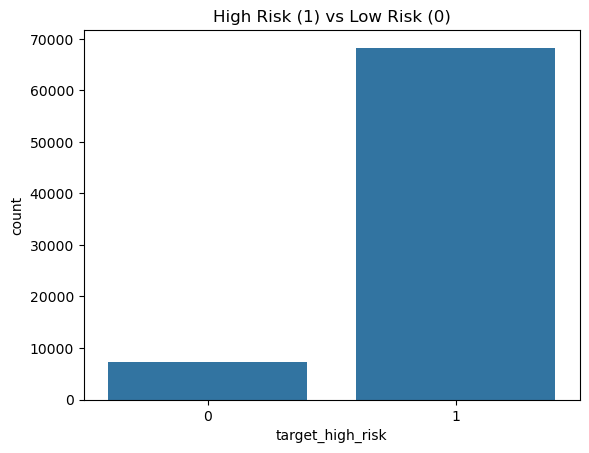

In [131]:
print(train_df['target_high_risk'].value_counts(normalize=True))
sns.countplot(x='target_high_risk', data=train_df)
plt.title('High Risk (1) vs Low Risk (0)')
plt.show()

In [132]:
null_count = train_df.isnull().mean().sort_values(ascending=False)
print("Sparsest Features (% Missing):")
print(null_count.head(50))

Sparsest Features (% Missing):
bot_russkill                       1.0
modify_security_center_warnings    1.0
prevents_safeboot                  1.0
virus                              1.0
mpr.dll                            1.0
iertutil.dll                       1.0
infostealer_keylog                 1.0
multiple_useragents                1.0
origin_langid                      1.0
linkinfo.dll                       1.0
mlang.dll                          1.0
msxml3.dll                         1.0
winsta.dll                         1.0
icm32.dll                          1.0
sqlite3.dll                        1.0
msls31.dll                         1.0
pstorec.dll                        1.0
nss3.dll                           1.0
msvcrt.dll                         1.0
crypt32.dll                        1.0
clbcatq.dll                        1.0
advapi32.dll                       1.0
ole32.dll                          1.0
ws2_32.dll                         1.0
davclnt.dll                      

In [133]:
duplicate_rows = duplicate_rows.loc[:, ~duplicate_rows.columns.duplicated()]
feature_cols = [c for c in train_df.columns if c not in ['target_high_risk', 'source_month']]
conflicts = duplicate_rows.groupby(feature_cols)['target_high_risk'].nunique()
print(f"Number of identical samples with conflicting targets: {(conflicts > 1).sum()}")

Number of identical samples with conflicting targets: 0


Defining a function to clean split dataframes

In [134]:
def data_clean(train_df, val_df, test_df, sparsity_threshold=0.99):
    # Dropping source_month
   train = train_df.loc[:, ~train_df.columns.duplicated()]
   val = val_df.loc[:, ~val_df.columns.duplicated()]
   test = test_df.loc[:, ~test_df.columns.duplicated()]

   cols_to_drop = ['source_month'] if 'source_month' in train.columns else []
    
    # Checking for constant columns
   for col in train.columns:
     if train[col].nunique() <= 1:
       cols_to_drop.append(col)
    
    # Checking for sparse columns
   null_pct = train.isnull().mean()
   sparse_cols = null_pct[null_pct > sparsity_threshold].index.tolist()
   cols_to_drop.extend(sparse_cols)
    
    # Unique list of all columns to remove
   final_drop_list = list(set(cols_to_drop))

    # Applying the SAME drops and removing duplicates from all sets
   def apply_clean(df):
        return df.drop(columns=final_drop_list, errors='ignore').drop_duplicates()

   return apply_clean(train), apply_clean(val), apply_clean(test)

train_cl, val_cl, test_cl = data_clean(train_df, val_df, test_df)

Reviewing clean data

Constant columns remaining: 0
Duplicate rows remaining: 0
float64    165
int64        1
Name: count, dtype: int64


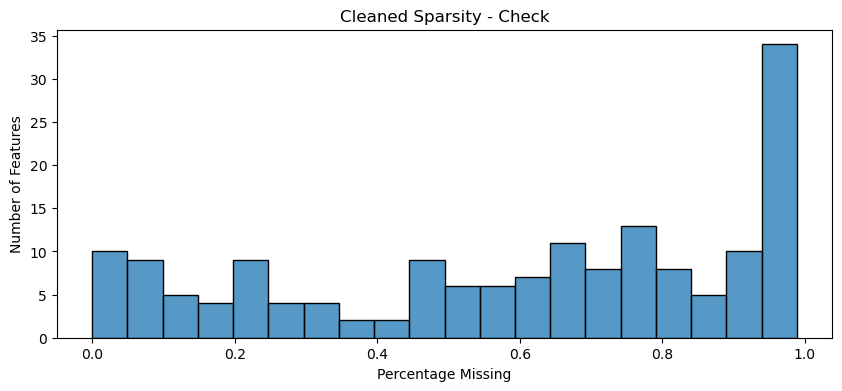

In [135]:
remaining_constants = [col for col in train_cl.columns if train_cl[col].nunique() <= 1]
print(f"Constant columns remaining: {len(remaining_constants)}")

final_dupes = train_cl.duplicated().sum()
print(f"Duplicate rows remaining: {final_dupes}")

print(train_cl.dtypes.value_counts())
if 'source_month' in train_cl.columns:
    print("Data leaked")
    
null_check = train_cl.isnull().mean()
plt.figure(figsize=(10, 4))
sns.histplot(null_check, bins=20)
plt.title('Cleaned Sparsity - Check')
plt.xlabel('Percentage Missing')
plt.ylabel('Number of Features')
plt.show()

# 4: Feature engineering
Engineering features using the provided mapping and features CSV

In [136]:
def features(df, mapping):
    ft_df = df.copy()

    # Defining categories from the CSV
    cats = mapping['feature_type'].unique()

    for cat in cats:
        categories = mapping[mapping['feature_type'] == cat]['feature_name'].tolist()
        # Identifying features that survived clean
        ex_features = [f for f in categories if f in ft_df.columns]

        if ex_features:
            ft_df[f'total_{cat.split("_")[0]}_intensity'] = ft_df[ex_features].sum(axis=1, min_count=1)

    return ft_df

# Applying function to the splits
train_f = features(train_cl, mapping)
val_f = features(val_cl, mapping)
test_f = features(test_cl, mapping)

# List your new aggregate features
intensity_cols = [c for c in train_f.columns if 'intensity' in c]
print("New Features Created:", intensity_cols)

# Check the distribution of one of them
print("\nSummary Statistics for Call Intensity:")
print(train_f['total_call_intensity'].describe())
                  

New Features Created: ['total_call_intensity', 'total_registry_intensity', 'total_file_intensity', 'total_misc_intensity']

Summary Statistics for Call Intensity:
count     46441.000000
mean       7284.421266
std       14378.882049
min           1.000000
25%         912.000000
50%        2148.000000
75%        5311.000000
max      245410.000000
Name: total_call_intensity, dtype: float64


In [137]:
new_feat = ['total_call_intensity', 'total_registry_intensity', 'total_file_intensity', 'total_misc_intensity']
print(train_f[new_feat + ['target_high_risk']].corr()['target_high_risk'])

total_call_intensity        0.089464
total_registry_intensity   -0.000846
total_file_intensity        0.035581
total_misc_intensity        0.031847
target_high_risk            1.000000
Name: target_high_risk, dtype: float64


# Modelling
Splitting into X and Y

In [138]:
# Defining 'targ' (target column)
targ = 'target_high_risk'

# Splitting
X_train = train_f.drop(columns=[targ])
y_train = train_f[targ]

X_val = val_f.drop(columns=[targ])
y_val = val_f[targ]

X_test = test_f.drop(columns=[targ])
y_test = test_f[targ]

print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(46444, 169)
(11166, 169)
(11181, 169)


#### Creating a baseline model for comparison

In [139]:
X_train_temp = X_train.fillna(0)
X_val_temp = X_val.fillna(0)
X_test_temp = X_test.fillna(0)

log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(max_iter=1000, random_state=42))

log_reg.fit(X_train_temp, y_train)

log_predict = log_reg.predict(X_val_temp)

print(classification_report(y_val, log_predict, zero_division=0))

              precision    recall  f1-score   support

           0       0.72      0.08      0.14      1293
           1       0.89      1.00      0.94      9888

    accuracy                           0.89     11181
   macro avg       0.81      0.54      0.54     11181
weighted avg       0.87      0.89      0.85     11181



#### Defining XGBoost Classification Model

####  Creating Random Search CV function to find Hyperparameters

In [140]:
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)

scale_ratio = neg / pos

parameters = {
    'n_estimators': randint(200, 600),
    'learning_rate': uniform(0.05, 0.15),
    'max_depth': randint(3, 7),
    'reg_alpha': uniform(0, 1),
    'reg_lambda': uniform(0, 1),
    'subsample': uniform(0.7, 0.3),
    'colsample_bytree': uniform(0.7, 0.3),
    'scale_pos_weight': uniform(scale_ratio * 0.5, scale_ratio)}

xgb_param = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    tree_method="hist"
)

srch = RandomizedSearchCV(xgb_param, parameters, cv=3, 
                          n_iter=20, scoring='f1', n_jobs=-1, verbose=2, random_state=42)

srch.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


,estimator,"XGBClassifier...ree=None, ...)"
,param_distributions,"{'colsample_bytree': <scipy.stats....x7f5fcd75c2d0>, 'learning_rate': <scipy.stats....x7f6003379700>, 'max_depth': <scipy.stats....x7f5fce9b4270>, 'n_estimators': <scipy.stats....x7f5fda97b570>, ...}"
,n_iter,20
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


After fitting model - defining new model name and attaching optimal parameters.

In [141]:
# Defining a loop to print all necessary performance parameters
if hasattr(srch, 'best_params_'):
    print("Best Params:", srch.best_params_)
    print("Best CV Score:", srch.best_score_)
    
    xgb_model = srch.best_estimator_
    
    # Getting Validation set possibilities
    val_probs = xgb_model.predict_proba(X_val)[:, 1]
    # Threshold tuning
    best_threshold = 0.5
    best_metrics = (0, 0)

    for threshold in np.arange(0.30, 0.71, 0.01):
        preds = (val_probs >= threshold).astype(int)

        precision = precision_score(y_val, preds)
        recall = recall_score(y_val, preds)

        if precision >= 0.90 and recall >= 0.90:
            best_threshold = threshold
            best_metrics = (precision, recall)
            break
  
    # performance on validation set
    print(f"\nThreshold: {best_threshold}")
    val_preds = (val_probs >= best_threshold).astype(int)
    print("\n Validation report")
    print(classification_report(y_val, val_preds))

    # performance on test set
    test_probs = xgb_model.predict_proba(X_test)[:, 1]
    test_preds = (test_probs >= best_threshold).astype(int)
    print("\n Test report")
    print(classification_report(y_test, test_preds))

else:
    print("Failed search.") # Just in case of failure

Best Params: {'colsample_bytree': np.float64(0.9598528437324805), 'learning_rate': np.float64(0.14016725176148132), 'max_depth': 6, 'n_estimators': 330, 'reg_alpha': np.float64(0.020584494295802447), 'reg_lambda': np.float64(0.9699098521619943), 'scale_pos_weight': np.float64(0.17968847732626825), 'subsample': np.float64(0.7637017332034828)}
Best CV Score: 0.9325288127084134

Threshold: 0.3

 Validation report
              precision    recall  f1-score   support

           0       0.59      0.64      0.61      1293
           1       0.95      0.94      0.95      9888

    accuracy                           0.91     11181
   macro avg       0.77      0.79      0.78     11181
weighted avg       0.91      0.91      0.91     11181


 Test report
              precision    recall  f1-score   support

           0       0.60      0.67      0.63      1290
           1       0.96      0.94      0.95      9876

    accuracy                           0.91     11166
   macro avg       0.78    

### Model Visualisation

Visualising the Precision-Recall Curve
Comparing both the baseline (Logistic regression) and XGBoost model

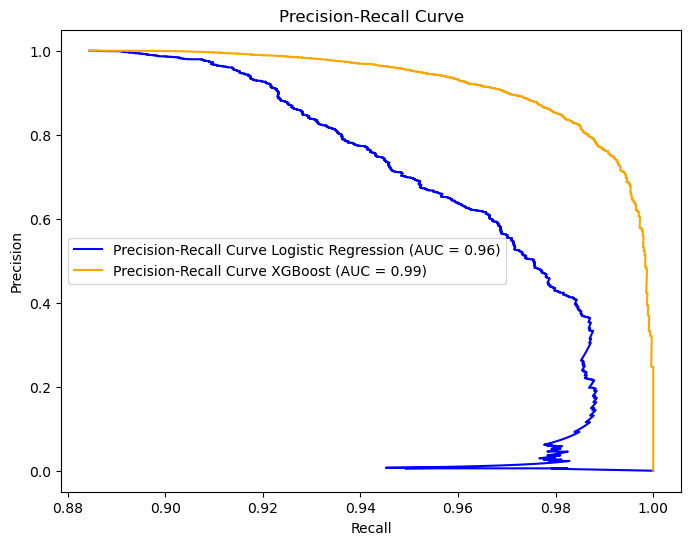

In [142]:
# Defining Logistic Regression probabilities variable (for the purpose of the curve/ model comparison)
log_probs = log_reg.predict_proba(X_test_temp)[:, 1]

precision_log, recall_log, thresholds_log =  precision_recall_curve(y_test, log_probs)
auc_log = auc(recall_log, precision_log)

precision_xgb, recall_xgb, thresholds_xgb = precision_recall_curve(y_test, test_probs)
auc_xgb = auc(recall_xgb, precision_xgb)

plt.figure(figsize=(8, 6))
plt.plot(precision_log, recall_log, color='blue', label=f'Precision-Recall Curve Logistic Regression (AUC = {auc_log:.2f})')
plt.plot(precision_xgb, recall_xgb, color='orange', label=f'Precision-Recall Curve XGBoost (AUC = {auc_xgb:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.savefig("Precision_recall_curve.png")
plt.show()

Viewing Model Tree

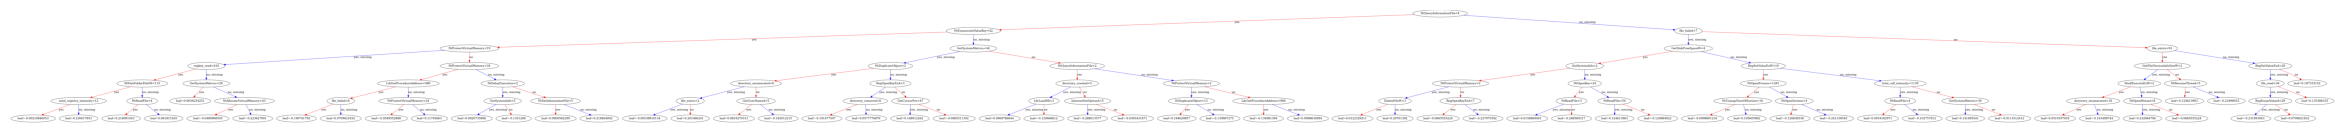

In [143]:
fig, ax = plt.subplots(figsize=(30, 15))
xgb.plot_tree(xgb_model, tree_idx=0, ax=ax)
plt.savefig("xgboost_tree.png", dpi=300, bbox_inches='tight')
plt.show()

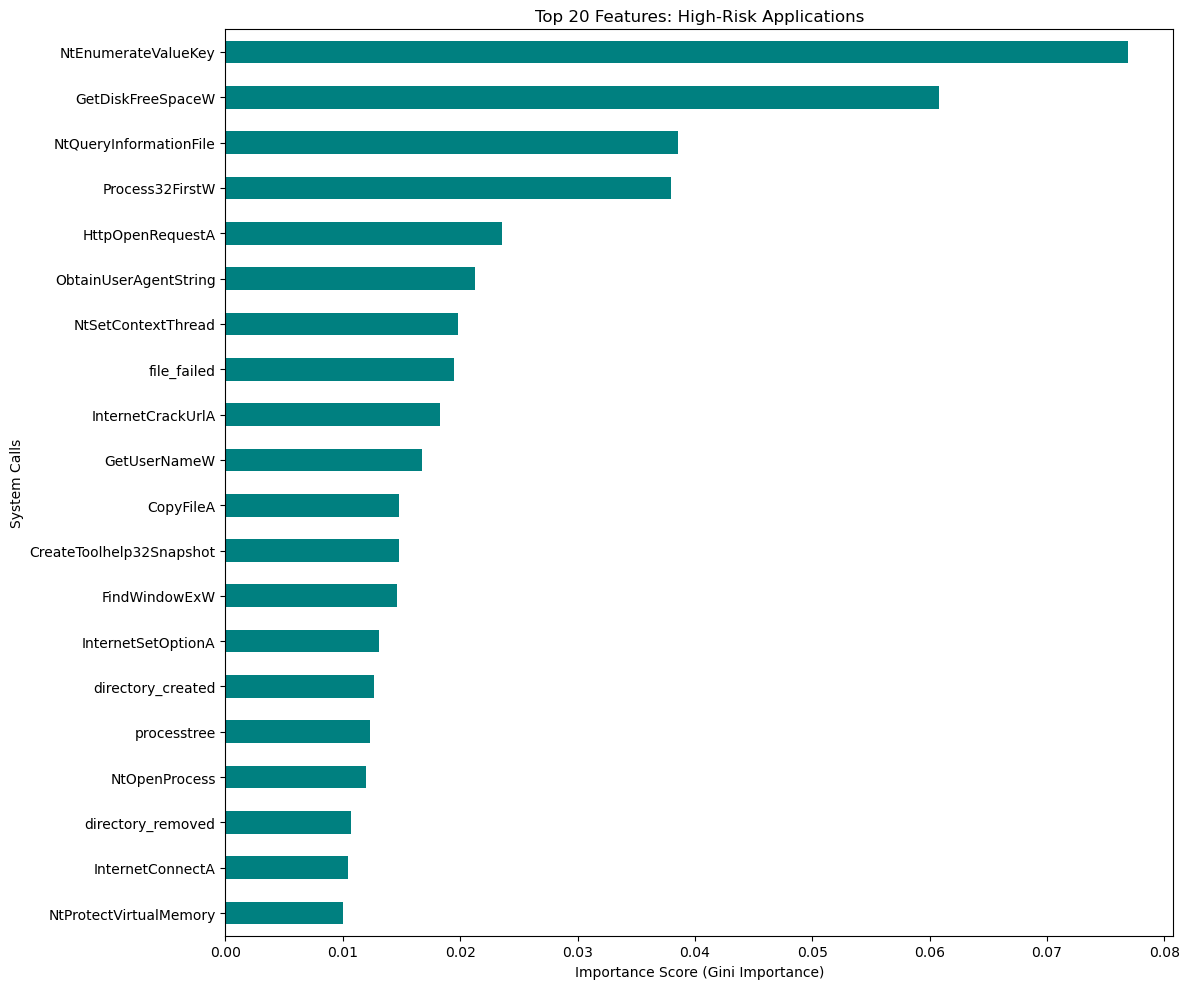

In [144]:
plt.figure(figsize=(12, 10))
feat_importances = pd.Series(xgb_model.feature_importances_, index=X_train.columns)

# Gathering top 20 Features | API calls
feat_importances.nlargest(20).plot(kind='barh', color='teal')

plt.title("Top 20 Features: High-Risk Applications")
plt.xlabel("Importance Score (Gini Importance)")
plt.ylabel("System Calls")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

# 5: Packaging Model using pickle

In [145]:
xgb_model_pack = 'xgboost_model.pkl'

with open (xgb_model_pack, 'wb') as file:
    pickle.dump(xgb_model, file)

print(f"Model saved - {xgb_model_pack}")

Model saved - xgboost_model.pkl


In [146]:
train_len = len(X_train)
val_len = len(X_val)
test_len = len(X_test)

with open('data_len.txt', 'w') as f:
    f.write(f"Train: {train_len}\n")
    f.write(f"Val: {val_len}\n")
    f.write(f"Test: {test_len}\n")
    f.write(f"Features: 167\n")

[CV] END colsample_bytree=0.7545474901621302, learning_rate=0.07751067647801507, max_depth=6, n_estimators=513, reg_alpha=0.5247564316322378, reg_lambda=0.43194501864211576, scale_pos_weight=0.10670234880276099, subsample=0.8835558684167137; total time=  23.8s
[CV] END colsample_bytree=0.8777243706586126, learning_rate=0.05696756190799966, max_depth=5, n_estimators=334, reg_alpha=0.17052412368729153, reg_lambda=0.06505159298527952, scale_pos_weight=0.19539155235433464, subsample=0.9896896099223678; total time=  10.2s
[CV] END colsample_bytree=0.7554563366576581, learning_rate=0.19543769416468376, max_depth=4, n_estimators=243, reg_alpha=0.9394989415641891, reg_lambda=0.8948273504276488, scale_pos_weight=0.148058887796173, subsample=0.976562270506935; total time=   6.5s
[CV] END colsample_bytree=0.7265477506155757, learning_rate=0.07939742936287178, max_depth=3, n_estimators=389, reg_alpha=0.32533033076326434, reg_lambda=0.388677289689482, scale_pos_weight=0.10402138806011317, subsample